# Diffusion Models Session – Part 4: Latent Diffusion & Stable Diffusion

**Alejandro Lancho Serrano, Vanessa Gómez Verdejo, Pablo Martínez Olmos, Emilio Parrado Hernández**

Departamento de Teoría de la Señal y Comunicaciones

**Universidad Carlos III de Madrid**

<img src='http://www.tsc.uc3m.es/~emipar/BBVA/INTRO/img/logo_uc3m_foot.jpg' width=400 />

## Table of contents
1. [Recap and objectives](#recap)
2. [Setup and data](#setup)
3. [A tiny VAE](#vae)
4. [Diffusion in latent space](#ldm)
5. [The real thing: text-to-image at scale](#sd)
6. [Discussion](#discussion)


## Recap and objectives <a id="recap"></a>

Across Parts 1–3 we built diffusion in pixel space: a fixed forward noising, a network trained to predict the noise, and DDPM/DDIM samplers. Everything rested on one identity, $x_t=\sqrt{\bar\alpha_t}\,x_0+\sqrt{1-\bar\alpha_t}\,\varepsilon$, and one job for the network: estimate the missing clean signal.

Here we make the last jump and connect to real systems. The idea is short:

> Nothing in the diffusion machinery cares that $x$ is an image. If we first **compress** images into a small **latent** with an autoencoder and run the *exact same* diffusion there, we get **latent diffusion** — much cheaper, and the design behind Stable Diffusion.

This final part has three steps: build a tiny VAE for MNIST, run our own class-conditional diffusion in its latent space, and then run a modern text-to-image model in a few lines to see the same idea at full scale.


## Why move diffusion into a latent space?

Latent diffusion is not just a stepping stone to Stable Diffusion; it buys three concrete things.

- **Cost scales with dimension.** Each denoising step runs the network over the whole input, hundreds or thousands of times per sample, so the bill is proportional to the number of values being diffused. Our MNIST latent holds $4\times7\times7=196$ numbers against $784$ pixels; Stable Diffusion compresses a $512\times512$ image into a $64\times64$ latent, a roughly $48\times$ reduction. That is the difference between minutes and seconds, in both training and sampling.
- **Division of labour.** Most pixels are predictable texture and high-frequency detail that carry little meaning. The autoencoder learns that part once (perceptual compression) and the diffusion model spends its capacity on the structure that actually varies (semantic content), instead of repeatedly repainting fine pixel noise at every step.
- **A reusable, conditioning-friendly space.** One good autoencoder serves many downstream models, and the compact latent is where conditioning plugs in cleanly: a label here, a sentence via cross-attention in Stable Diffusion.

The price is an extra encode/decode and a result only as sharp as the decoder allows. For anything beyond toy resolutions, that trade is overwhelmingly worth it, which is why essentially every modern image, audio, and video generator is a latent diffusion model.


## Setup and data <a id="setup"></a>

We use **MNIST** (28×28 grayscale digits, labels 0–9). It is small enough that both the VAE and the latent diffusion model train in a few minutes, and the labels let us condition generation.


In [9]:
import os, math, time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils as vutils

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(0)
print("Using device:", device)


Using device: cuda


train batches: 469


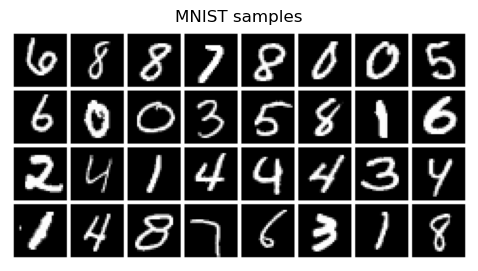

In [10]:
# MNIST: a single training loader is all we need for the demo
BATCH_SIZE = 128
transform = transforms.ToTensor()          # pixels in [0, 1]
train_ds = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
print("train batches:", len(train_loader))

imgs, labels = next(iter(train_loader))
grid = vutils.make_grid(imgs[:32], nrow=8, pad_value=1.0)
plt.figure(figsize=(6, 3)); plt.axis('off')
plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap='gray'); plt.title("MNIST samples"); plt.show()


## A tiny VAE <a id="vae"></a>

A **variational autoencoder** compresses an image $x$ into a small latent $z$ and decodes it back. The encoder outputs a Gaussian $q_\phi(z\mid x)=\mathcal{N}(\mu_\phi(x),\sigma_\phi^2(x))$; we sample $z=\mu+\sigma\varepsilon$ (the reparameterization trick) and the decoder reconstructs $\hat x$. Training minimizes a reconstruction term plus a KL term that keeps the latent close to $\mathcal{N}(0,I)$, so the latent space is compact and roughly unit-scale:
$$ \mathcal{L}=\underbrace{\text{recon}(x,\hat x)}_{\text{BCE}}+\beta\,D_{\mathrm{KL}}\!\big(q_\phi(z\mid x)\,\|\,\mathcal{N}(0,I)\big). $$

Our latent is a small spatial map of shape $(4,7,7)$: 196 numbers instead of 784 pixels, and shaped as a feature map so a convolutional denoiser can act on it directly. For diffusion we will use the encoder mean $\mu$ as the latent.


In [11]:
# Tiny convolutional VAE with a (4, 7, 7) spatial latent
class ConvVAE(nn.Module):
    def __init__(self, z_channels=4):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Conv2d(1, 32, 4, stride=2, padding=1), nn.ReLU(inplace=True),   # 28 -> 14
            nn.Conv2d(32, 64, 4, stride=2, padding=1), nn.ReLU(inplace=True),  # 14 -> 7
        )
        self.enc_mu     = nn.Conv2d(64, z_channels, 1)
        self.enc_logvar = nn.Conv2d(64, z_channels, 1)
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(z_channels, 64, 4, stride=2, padding=1), nn.ReLU(inplace=True),  # 7 -> 14
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1), nn.ReLU(inplace=True),          # 14 -> 28
            nn.Conv2d(32, 1, 3, padding=1),                                                     # logits
        )

    def encode(self, x):
        h = self.enc(x)
        return self.enc_mu(h), self.enc_logvar(h)

    def reparameterize(self, mu, logvar):
        return mu + torch.exp(0.5 * logvar) * torch.randn_like(mu)

    def decode(self, z):
        return self.dec(z)                # logits

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

def vae_loss(x, x_logits, mu, logvar, beta=1.0):
    recon = F.binary_cross_entropy_with_logits(x_logits, x, reduction='sum') / x.size(0)
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    return recon + beta * kl, recon, kl


In [12]:
# Train or load the VAE (a few epochs give clean MNIST reconstructions)
os.makedirs('./checkpoints', exist_ok=True)
ckpt_vae = './checkpoints/mnist_vae.pt'

vae = ConvVAE(z_channels=4).to(device)
if os.path.exists(ckpt_vae):
    vae.load_state_dict(torch.load(ckpt_vae, map_location=device))
    print("Loaded VAE checkpoint.")
else:
    opt = torch.optim.Adam(vae.parameters(), lr=2e-3)
    vae.train()
    for epoch in range(6):
        tot = 0.0
        for x, _ in train_loader:
            x = x.to(device)
            x_logits, mu, logvar = vae(x)
            # a light KL weight keeps the latent compact while preserving digit detail
            loss, _, _ = vae_loss(x, x_logits, mu, logvar, beta=0.5)
            opt.zero_grad(); loss.backward(); opt.step()
            tot += loss.item()
        print(f"VAE epoch {epoch+1}/6  loss={tot/len(train_loader):.2f}")
    torch.save(vae.state_dict(), ckpt_vae); print("Trained and saved VAE.")
vae.eval();


Loaded VAE checkpoint.


/tmp/ipykernel_670667/2717862924.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  vae.load_state_dict(torch.load(ckpt_vae, map_location=device))


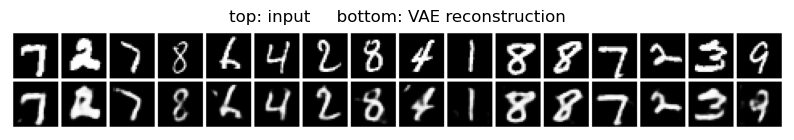

In [13]:
# Reconstruction check: top row inputs, bottom row VAE outputs
with torch.no_grad():
    x, _ = next(iter(train_loader)); x = x.to(device)[:16]
    x_hat = torch.sigmoid(vae(x)[0])
grid = vutils.make_grid(torch.cat([x, x_hat], 0).cpu(), nrow=16, pad_value=1.0)
plt.figure(figsize=(10, 1.6)); plt.axis('off')
plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap='gray')
plt.title("top: input     bottom: VAE reconstruction"); plt.show()


## Diffusion in latent space <a id="ldm"></a>

This is the whole trick: run the diffusion we already know, but on $z$ instead of $x$.

1. Encode the image to its latent $z_0=\mu_\phi(x)$ and normalize it to roughly unit variance (Stable Diffusion uses a fixed scaling factor for exactly this reason).
2. Apply the identical forward identity, $z_t=\sqrt{\bar\alpha_t}\,z_0+\sqrt{1-\bar\alpha_t}\,\varepsilon$, and train a denoiser to predict the noise: $\mathcal{L}=\mathbb{E}\,\|\varepsilon-\varepsilon_\theta(z_t,t,c)\|^2$, with $c$ the digit label.
3. Sample with DDIM in latent space, then **decode** the final $z_0$ back to pixels with the VAE.

The math is unchanged from Parts 1–3; only the domain shrank from $1\times28\times28$ pixels to $4\times7\times7$ latents. That is why latent diffusion is faster, and why it scales to high-resolution images in real systems.


In [14]:
# --- diffusion schedule (same construction as Parts 1-3) ---
timesteps = 500
beta1, beta2 = 1e-4, 0.02
b_t = (beta2 - beta1) * torch.linspace(0, 1, timesteps + 1, device=device) + beta1
a_t = 1.0 - b_t
ab_t = torch.cumsum(a_t.log(), dim=0).exp(); ab_t[0] = 1.0

# --- latent normalization: keep z0 ~ unit scale (cf. Stable Diffusion's scaling factor) ---
with torch.no_grad():
    x, _ = next(iter(train_loader))
    mu, _ = vae.encode(x.to(device))
    latent_scale = mu.std().item()
print(f"latent_scale = {latent_scale:.3f}")

def encode_latents(x):
    with torch.no_grad():
        mu, _ = vae.encode(x.to(device))
    return mu / latent_scale                      # normalized clean latent z0

def q_sample(z0, t_idx, eps):                     # forward identity in latent space
    ab = ab_t[t_idx].view(-1, 1, 1, 1)
    return ab.sqrt() * z0 + (1.0 - ab).sqrt() * eps

@torch.no_grad()
def ddim_step(z, t_idx, t_prev_idx, eps_theta, eta=0.0):   # same DDIM step as Part 3, on z
    ab, ab_prev = ab_t[t_idx], ab_t[t_prev_idx]
    z0_hat = (z - (1.0 - ab).sqrt() * eps_theta) / ab.sqrt()
    sigma = eta * ((1.0 - ab_prev) / (1.0 - ab)).sqrt() * (1.0 - ab / ab_prev).sqrt()
    reused = (1.0 - ab_prev - sigma**2).clamp(min=0.0).sqrt() * eps_theta
    return ab_prev.sqrt() * z0_hat + reused + sigma * torch.randn_like(z)


latent_scale = 0.458


### The latent denoiser

A compact convolutional network predicts the noise in the $(4,7,7)$ latent. The timestep and class label are turned into a single conditioning vector and injected into **every** residual block as a learned scale and shift (FiLM). Injecting the label throughout, rather than once, is what makes the class signal actually stick.

As in Part 2 we drop the label on about 10% of examples, replacing it with a "null" token. The one model therefore learns both the conditional noise $\varepsilon_\theta(z_t,t,c)$ and the unconditional $\varepsilon_\theta(z_t,t)$, which is exactly what **classifier-free guidance** needs at sampling time.


In [15]:
# Conditional latent denoiser: predicts eps in a (4,7,7) latent, with FiLM conditioning.
class FiLMResBlock(nn.Module):
    """Residual block whose features are scaled and shifted by the (time+class) conditioning."""
    def __init__(self, width, cond_dim):
        super().__init__()
        self.norm1 = nn.GroupNorm(8, width); self.conv1 = nn.Conv2d(width, width, 3, padding=1)
        self.norm2 = nn.GroupNorm(8, width); self.conv2 = nn.Conv2d(width, width, 3, padding=1)
        self.film  = nn.Linear(cond_dim, 2 * width)              # produces (scale, shift)
    def forward(self, h, cond):
        scale, shift = self.film(cond).chunk(2, dim=1)
        x = self.norm1(h)
        x = x * (1 + scale[:, :, None, None]) + shift[:, :, None, None]
        x = self.conv1(F.silu(x))
        x = self.conv2(F.silu(self.norm2(x)))
        return h + x

class LatentDenoiser(nn.Module):
    def __init__(self, z_ch=4, width=192, n_classes=10, t_dim=128, n_blocks=4):
        super().__init__()
        self.t_dim = t_dim
        self.c_emb = nn.Embedding(n_classes + 1, t_dim)         # last index = null label
        self.cond_mlp = nn.Sequential(nn.Linear(t_dim, width), nn.SiLU(), nn.Linear(width, width))
        self.in_conv = nn.Conv2d(z_ch, width, 3, padding=1)
        self.blocks = nn.ModuleList([FiLMResBlock(width, width) for _ in range(n_blocks)])
        self.out = nn.Sequential(nn.GroupNorm(8, width), nn.SiLU(), nn.Conv2d(width, z_ch, 3, padding=1))

    def time_embedding(self, t):                                # sinusoidal embedding of t in [0,1]
        half = self.t_dim // 2
        freqs = torch.exp(-math.log(10000.0) * torch.arange(half, device=t.device) / half)
        ang = (t[:, None] * 1000.0) * freqs[None, :]
        return torch.cat([ang.sin(), ang.cos()], dim=1)

    def forward(self, z, t, y):
        # t: (B,) in [0,1];  y: (B,) long class ids (n_classes index = null)
        cond = self.cond_mlp(self.time_embedding(t) + self.c_emb(y))
        h = self.in_conv(z)
        for blk in self.blocks:
            h = blk(h, cond)
        return self.out(h)


### Train or load the latent denoiser

One conditional model, trained on MNIST latents with the noise-prediction loss. This is a few minutes on a GPU and is cached afterward.


In [16]:
ckpt_den = './checkpoints/mnist_latent_denoiser.pt'
NULL = 10                                   # null-label token (enables unconditional + guidance)

denoiser = LatentDenoiser(z_ch=4, width=192, n_classes=10).to(device)
if os.path.exists(ckpt_den):
    denoiser.load_state_dict(torch.load(ckpt_den, map_location=device))
    print("Loaded denoiser checkpoint.")
else:
    opt = torch.optim.Adam(denoiser.parameters(), lr=2e-4)
    EPOCHS = 35
    denoiser.train()
    for epoch in range(EPOCHS):
        tot = 0.0
        for x, y in train_loader:
            y = y.to(device)
            z0 = encode_latents(x)                                   # (B, 4, 7, 7), unit-scale
            t_idx = torch.randint(1, timesteps + 1, (z0.size(0),), device=device)
            t_in = (t_idx / timesteps).float()
            eps = torch.randn_like(z0)
            zt = q_sample(z0, t_idx, eps)
            # drop the label ~10% of the time -> null token
            y_in = torch.where(torch.rand(y.shape, device=device) < 0.1, torch.full_like(y, NULL), y)
            eps_pred = denoiser(zt, t_in, y_in)
            loss = F.mse_loss(eps_pred, eps)
            opt.zero_grad(); loss.backward(); opt.step()
            tot += loss.item()
        if epoch % 5 == 0 or epoch == EPOCHS - 1:
            print(f"denoiser epoch {epoch+1}/{EPOCHS}  loss={tot/len(train_loader):.4f}")
    torch.save(denoiser.state_dict(), ckpt_den); print("Trained and saved denoiser.")
denoiser.eval();


denoiser epoch 1/35  loss=0.1831
denoiser epoch 6/35  loss=0.0952
denoiser epoch 11/35  loss=0.0885
denoiser epoch 16/35  loss=0.0843
denoiser epoch 21/35  loss=0.0825
denoiser epoch 26/35  loss=0.0811
denoiser epoch 31/35  loss=0.0796
denoiser epoch 35/35  loss=0.0788
Trained and saved denoiser.


### Sample and decode (with guidance)

We run deterministic DDIM ($\eta=0$) on the latent from pure noise, then decode. We also apply **classifier-free guidance**: at each step we combine the conditional and unconditional noise predictions,
$$ \hat\varepsilon = \varepsilon_\theta(z_t,t) + w\,\big[\varepsilon_\theta(z_t,t,c) - \varepsilon_\theta(z_t,t)\big], $$
where the unconditional term uses the null label. The weight $w$ controls how strongly the sample commits to the requested digit: $w=1$ is the plain conditional model, and $w>1$ sharpens class identity. This is the single biggest lever on sample quality here.


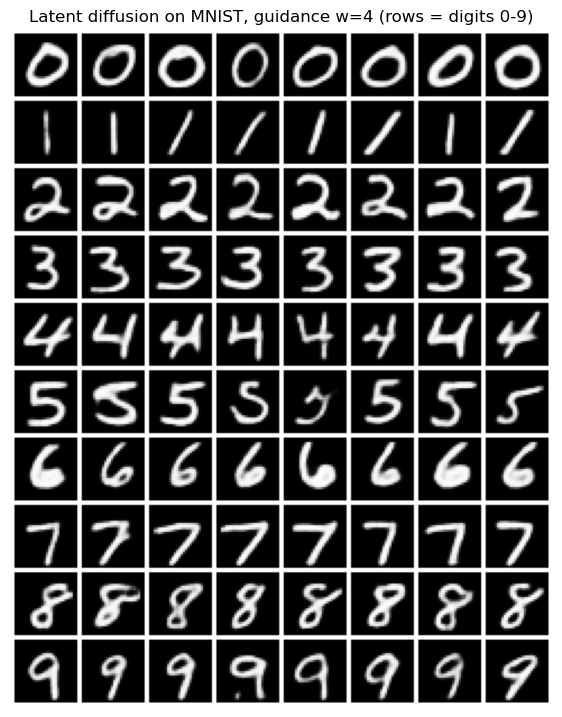

In [17]:
@torch.no_grad()
def sample_latent(labels, n_steps=50, eta=0.0, guidance=4.0):
    y = labels.to(device)
    n = y.shape[0]
    null = torch.full_like(y, NULL)
    z = torch.randn(n, 4, 7, 7, device=device)                 # pure latent noise z_T
    step = max(1, timesteps // n_steps)
    for i in range(timesteps, 0, -step):
        t_prev = max(0, i - step)
        t_in = torch.full((n,), i / timesteps, device=device)
        eps_c = denoiser(z, t_in, y)
        if guidance != 1.0:
            eps_u = denoiser(z, t_in, null)                    # unconditional (computed once)
            eps = eps_u + guidance * (eps_c - eps_u)           # classifier-free guidance
        else:
            eps = eps_c
        z = ddim_step(z, i, t_prev, eps, eta=eta)
        if t_prev == 0:
            break
    return torch.sigmoid(vae.decode(z * latent_scale))         # un-normalize, then decode

# Conditional generation: 8 samples of each digit 0..9 (one digit per row), guidance w=4
labels = torch.tensor([d for d in range(10) for _ in range(8)])
imgs = sample_latent(labels, n_steps=50, guidance=4.0)
grid = vutils.make_grid(imgs.cpu(), nrow=8, pad_value=1.0)
plt.figure(figsize=(7, 9)); plt.axis('off')
plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap='gray')
plt.title("Latent diffusion on MNIST, guidance w=4 (rows = digits 0-9)"); plt.show()


### What guidance does

The same labels, sampled with weak and strong guidance. Without guidance ($w=1$) the digits are soft and sometimes ambiguous; turning guidance up makes each sample commit to its class. (Too much guidance eventually over-sharpens and loses variety, so $w$ in roughly $2$–$6$ is the useful range.)


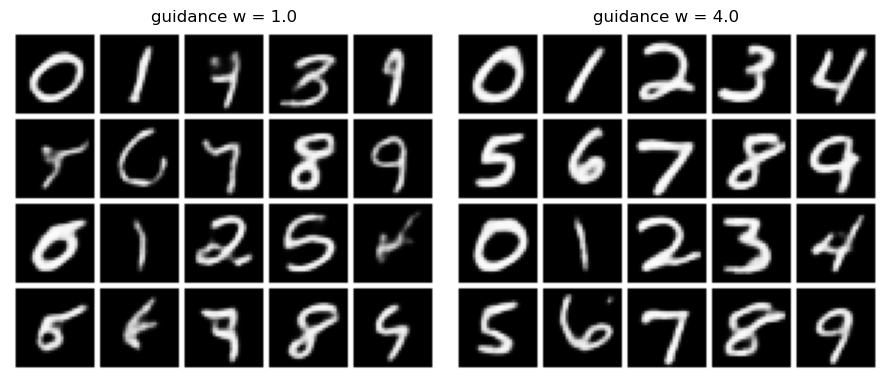

In [18]:
labels_cmp = torch.arange(10).repeat(2)        # digits 0..9, twice
fig, axs = plt.subplots(1, 2, figsize=(9, 5))
for ax, w in zip(axs, [1.0, 4.0]):
    g = vutils.make_grid(sample_latent(labels_cmp, n_steps=50, guidance=w).cpu(), nrow=5, pad_value=1.0)
    ax.imshow(g.permute(1, 2, 0).squeeze(), cmap='gray'); ax.axis('off')
    ax.set_title(f"guidance w = {w}")
plt.tight_layout(); plt.show()


## The real thing: text-to-image at scale <a id="sd"></a>

Everything above is, in miniature, how modern text-to-image models work. **Stable Diffusion** is a latent diffusion model with three parts:

1. a **VAE** that compresses images to a latent (ours did this for MNIST),
2. a **U-Net denoiser** trained with the noise-prediction loss (ours did this on latents),
3. a **text encoder** (CLIP) whose embeddings condition the denoiser through cross-attention, replacing our one-hot label with a whole sentence.

We will run **SDXL-Turbo**, a distilled Stable Diffusion XL. It is the same latent diffusion, compressed to **1–4 sampling steps** by *adversarial diffusion distillation* — the same few-step idea we previewed at the end of Part 3. No guidance term is needed (`guidance_scale=0.0`). On a GPU it produces a 512×512 image in about a second.

> Runs best on a GPU runtime (Colab: Runtime → Change runtime type → GPU). The first run downloads the weights. The classic `runwayml/stable-diffusion-v1-5` repo was taken down in 2024; its mirror is `stable-diffusion-v1-5/stable-diffusion-v1-5` if you want the original 50-step model instead.


In [19]:
# One-time install on Colab (uncomment if needed):
# !pip install -q --upgrade diffusers transformers accelerate

import torch
from diffusers import AutoPipelineForText2Image

sd_device = "cuda" if torch.cuda.is_available() else "cpu"
sd_dtype  = torch.float16 if sd_device == "cuda" else torch.float32

pipe = AutoPipelineForText2Image.from_pretrained(
    "stabilityai/sdxl-turbo",
    torch_dtype=sd_dtype,
    variant=("fp16" if sd_device == "cuda" else None),
).to(sd_device)
print("Loaded SDXL-Turbo on", sd_device)


/home/alancho/.conda/envs/ipynb_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading pipeline components...: 100%|██████████| 7/7 [00:00<00:00, 21.44it/s]


Loaded SDXL-Turbo on cuda


100%|██████████| 2/2 [00:00<00:00, 11.41it/s]
/home/alancho/.conda/envs/ipynb_env/lib/python3.11/site-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(
100%|██████████| 2/2 [00:00<00:00, 24.51it/s]


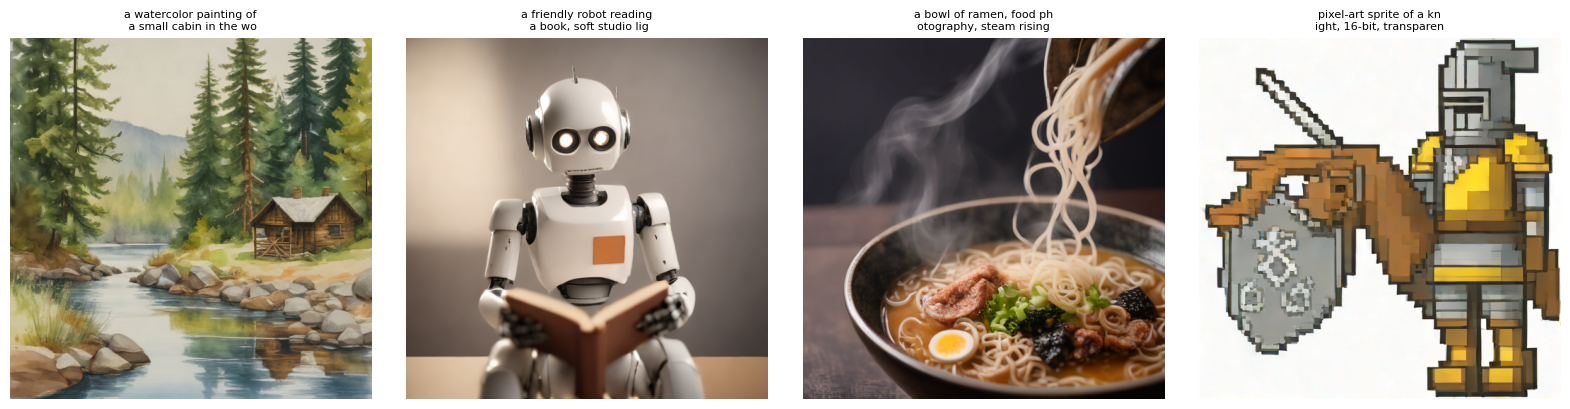

In [20]:
# A few prompts, 2 steps each, no guidance. Edit freely and rerun.
prompts = [
    "a watercolor painting of a small cabin in the woods by a river",
    "a friendly robot reading a book, soft studio lighting",
    "a bowl of ramen, food photography, steam rising",
    "pixel-art sprite of a knight, 16-bit, transparent background",   # a nod to Parts 1-3
]

fig, axs = plt.subplots(1, len(prompts), figsize=(4 * len(prompts), 4))
for ax, p in zip(axs, prompts):
    image = pipe(prompt=p, num_inference_steps=2, guidance_scale=0.0).images[0]
    ax.imshow(image); ax.axis("off"); ax.set_title("\n".join([p[:24], p[24:48]]), fontsize=8)
plt.tight_layout(); plt.show()


## Discussion <a id="discussion"></a>

- **One idea, two domains.** Latent diffusion is the pixel-space diffusion of Parts 1–3 run on a compressed latent. The forward identity, the noise-prediction loss, and the DDIM sampler are identical; only the space changed.
- **Why it wins.** A $(4,7,7)$ latent holds far fewer numbers than a $1\times28\times28$ image, so training and sampling are cheaper, and the VAE decoder restores the fine pixel detail. At scale, this is what makes high-resolution generation practical.
- **Conditioning.** A one-hot digit label here; a sentence encoded by CLIP and injected through cross-attention in Stable Diffusion. Same role: tell the denoiser what to aim for.
- **Speed.** DDIM cut the step count in Part 3; SDXL-Turbo goes further, distilling the sampler down to 1–4 steps. The reverse process was never unique, and that freedom is what modern fast samplers exploit.
- **The whole arc.** Add noise, predict the noise, step back, do it in a latent, condition on text, distill the steps. That is a working picture of how today's image, audio, and video generators are built.


## Acknowledgments

- MNIST by Yann LeCun et al.
- Latent diffusion: Rombach et al., *High-Resolution Image Synthesis with Latent Diffusion Models* (2022).
- Stable Diffusion / SDXL by CompVis, Stability AI, and LAION; **SDXL-Turbo** (adversarial diffusion distillation) by Stability AI; demo via Hugging Face `diffusers`.
